In [19]:
# ============================================
# MODÉLISATION AVANCÉE - VERSION FINALE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_log_error, mean_squared_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor, VotingRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("MODÉLISATION AVANCÉE - OBJECTIF 1ÈRE PLACE")
print("=" * 70)

# 1. CHARGER LES DATASETS
print("\n1. CHARGEMENT DES DATASETS")
print("-" * 50)

# Charger train (avec toutes les features)
df_train = pd.read_csv('../data/train_enriched_avance.csv')
print(f"✅ Train chargé: {df_train.shape[0]} lignes, {df_train.shape[1]} colonnes")

# Charger test (déjà enrichi)
df_test = pd.read_csv('../data/test_enriched.csv')
print(f"✅ Test chargé: {df_test.shape[0]} lignes, {df_test.shape[1]} colonnes")

MODÉLISATION AVANCÉE - OBJECTIF 1ÈRE PLACE

1. CHARGEMENT DES DATASETS
--------------------------------------------------
✅ Train chargé: 1153 lignes, 66 colonnes
✅ Test chargé: 289 lignes, 51 colonnes


In [20]:
nb_biens_quartier = df_train.groupby('quartier').size().reset_index(name='nb_biens_quartier')
df_test = df_test.merge(nb_biens_quartier, on='quartier', how='left')

In [21]:
# Utiliser les mêmes limites que train
surface_min = df_train['surface_m2'].quantile(0.01)
surface_max = df_train['surface_m2'].quantile(0.99)
df_test['surface_winsorized'] = df_test['surface_m2'].clip(surface_min, surface_max)

In [22]:
# ============================================
# ÉTAPE 1: SÉLECTION DES FEATURES - CORRIGÉ
# ============================================

print("\n" + "=" * 70)
print("🎯 ÉTAPE 1: SÉLECTION DES FEATURES")
print("=" * 70)

# Définir la cible
target = 'prix'

# Features à EXCLURE (identifiants, textes, colonnes dérivées du prix)
cols_to_exclude = [
    # Identifiants et texte
    'id', 'titre', 'description', 'caracteristiques', 'adresse_osm', 'source',
    'date_publication', 'quartier', 'type_bien', 'saison',
    
    # Cible et dérivés directs du prix (data leakage!)
    'prix', 'log_prix', 'prix_m2', 'prix_par_piece',
    'prix_winsorized', 'prix_m2_winsorized', 'is_price_outlier',
    
    # Stats quartier basées sur le prix (data leakage!)
    'prix_moyen_quartier', 'prix_median_quartier', 'prix_m2_moyen_quartier'
]

# Features numériques à garder
feature_cols = [col for col in df_train.columns 
                if col not in cols_to_exclude 
                and col in df_train.columns 
                and df_train[col].dtype in ['int64', 'float64']]

print(f"\n✅ {len(feature_cols)} features sélectionnées:")

# Afficher par catégorie
print("\n📊 Features de base:")
base_features = [col for col in feature_cols if col in [
    'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'nb_pieces_total',
    'quartier_encoded', 'age_annonce', 'mois_publication', 'annee_publication', 'weekend'
]]
for col in base_features:
    print(f"   - {col}")

print("\n🗺️ Features géographiques:")
geo_features = [col for col in feature_cols if any(x in col for x in ['dist', 'pois', 'centre', 'plage'])]
for col in geo_features:
    print(f"   - {col}")

print("\n🔧 Features d'équipement:")
equip_features = [col for col in feature_cols if col.startswith('has_') or col in ['is_luxe', 'score_equipement']]
for col in equip_features:
    print(f"   - {col}")

print("\n📈 Features de ratio:")
ratio_features = [col for col in feature_cols if any(x in col for x in ['par_', 'pieces_'])]
for col in ratio_features:
    print(f"   - {col}")

print("\n🏷️ Features encodées:")
encoded_features = [col for col in feature_cols if col.startswith(('type_', 'saison_'))]
for col in encoded_features:
    print(f"   - {col}")

print("\n📊 Stats quartier (sans prix):")
quartier_stats_features = [col for col in feature_cols if col == 'nb_biens_quartier']
for col in quartier_stats_features:
    print(f"   - {col}")

print("\n🔄 Features de transformation:")
transform_features = [col for col in feature_cols if any(x in col for x in ['winsorized', 'outlier'])]
for col in transform_features:
    print(f"   - {col}")

# Créer X et y
X = df_train[feature_cols]
y = df_train[target]

print(f"\n📊 X shape: {X.shape}")
print(f"📊 y shape: {y.shape}")

# Vérification rapide
print("\n🔍 Vérification - Aucune feature basée sur le prix ne devrait être présente:")
price_based = [col for col in feature_cols if 'prix' in col]
if price_based:
    print(f"⚠️ Attention: {price_based} encore présents!")
else:
    print("✅ OK - Aucune feature 'prix' dans les prédicteurs")


🎯 ÉTAPE 1: SÉLECTION DES FEATURES

✅ 37 features sélectionnées:

📊 Features de base:
   - surface_m2
   - nb_chambres
   - nb_salons
   - nb_sdb
   - quartier_encoded
   - nb_pieces_total
   - age_annonce
   - mois_publication
   - annee_publication
   - weekend

🗺️ Features géographiques:
   - dist_centre_ville_km
   - dist_aeroport_km
   - dist_plage_km
   - nb_total_pois_1km
   - centre_x_plage
   - pois_x_centre
   - pois_x_plage

🔧 Features d'équipement:
   - has_garage
   - has_jardin
   - has_piscine
   - has_balcon
   - has_meuble
   - has_titre_foncier
   - is_luxe
   - score_equipement

📈 Features de ratio:
   - nb_pieces_total
   - surface_par_chambre
   - surface_par_sdb
   - pieces_par_sdb

🏷️ Features encodées:

📊 Stats quartier (sans prix):
   - nb_biens_quartier

🔄 Features de transformation:
   - surface_winsorized

📊 X shape: (1153, 37)
📊 y shape: (1153,)

🔍 Vérification - Aucune feature basée sur le prix ne devrait être présente:
✅ OK - Aucune feature 'prix' dans le

In [23]:
# ============================================
# ÉTAPE 2: SPLIT TRAIN/VALIDATION
# ============================================

print("\n" + "=" * 70)
print("ÉTAPE 2: SPLIT TRAIN/VALIDATION")
print("=" * 70)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Train set: {X_train.shape[0]} échantillons")
print(f"✅ Validation set: {X_val.shape[0]} échantillons")

# Définition de RMSLE
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)  # Éviter les négatifs
    log_true = np.log1p(y_true)
    log_pred = np.log1p(y_pred)
    return np.sqrt(np.mean((log_pred - log_true) ** 2))

# Scorer pour validation croisée
rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

print(f"\n📐 Métrique: RMSLE")
print(f"   - Baseline à battre: 0.997")
print(f"   - Objectif 5ème: 0.624")
print(f"   - Objectif 1ère: 0.559")


ÉTAPE 2: SPLIT TRAIN/VALIDATION
✅ Train set: 922 échantillons
✅ Validation set: 231 échantillons

📐 Métrique: RMSLE
   - Baseline à battre: 0.997
   - Objectif 5ème: 0.624
   - Objectif 1ère: 0.559


In [24]:
# ============================================
# ÉTAPE 3: MODÈLES DE BASE
# ============================================

print("\n" + "=" * 70)
print("🤖 ÉTAPE 3: MODÈLES DE BASE")
print("=" * 70)

base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

print(f"✅ {len(base_models)} modèles de base")


🤖 ÉTAPE 3: MODÈLES DE BASE
✅ 8 modèles de base


In [25]:
# ============================================
# ÉTAPE 4: VALIDATION CROISÉE RAPIDE
# ============================================

print("\n" + "=" * 70)
print("🔄 ÉTAPE 4: VALIDATION CROISÉE RAPIDE")
print("=" * 70)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
base_results = {}

for name, model in base_models.items():
    print(f"\n📊 Entraînement de {name}...")
    
    # Validation croisée
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, 
                                scoring=rmsle_scorer, n_jobs=-1)
    cv_scores = -cv_scores
    
    # Entraînement rapide
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    
    base_results[name] = {
        'CV RMSLE': cv_scores.mean(),
        'CV std': cv_scores.std(),
        'Val RMSLE': rmsle(y_val, y_pred_val)
    }
    
    print(f"   ✅ CV RMSLE: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"   ✅ Val RMSLE: {base_results[name]['Val RMSLE']:.4f}")

# Tableau comparatif
base_results_df = pd.DataFrame(base_results).T.round(4)
print("\n📋 RÉSULTATS DES MODÈLES DE BASE:")
print(base_results_df.sort_values('Val RMSLE'))

# Identifier les meilleurs
top_models = base_results_df.sort_values('Val RMSLE').head(3).index.tolist()
print(f"\n🏆 Top 3 modèles: {top_models}")


🔄 ÉTAPE 4: VALIDATION CROISÉE RAPIDE

📊 Entraînement de Linear Regression...
   ✅ CV RMSLE: 2.4994 (+/- 0.4606)
   ✅ Val RMSLE: 2.1128

📊 Entraînement de Ridge...
   ✅ CV RMSLE: 2.4983 (+/- 0.4617)
   ✅ Val RMSLE: 2.1134

📊 Entraînement de Lasso...
   ✅ CV RMSLE: 2.4994 (+/- 0.4606)
   ✅ Val RMSLE: 2.1128

📊 Entraînement de ElasticNet...
   ✅ CV RMSLE: 2.4987 (+/- 0.4619)
   ✅ Val RMSLE: 2.1133

📊 Entraînement de Random Forest...
   ✅ CV RMSLE: 0.7222 (+/- 0.0420)
   ✅ Val RMSLE: 0.6711

📊 Entraînement de Gradient Boosting...
   ✅ CV RMSLE: 0.7163 (+/- 0.0240)
   ✅ Val RMSLE: 0.6671

📊 Entraînement de XGBoost...
   ✅ CV RMSLE: 1.1019 (+/- 0.1966)
   ✅ Val RMSLE: 0.7359

📊 Entraînement de LightGBM...
   ✅ CV RMSLE: 1.2650 (+/- 0.5463)
   ✅ Val RMSLE: 1.0870

📋 RÉSULTATS DES MODÈLES DE BASE:
                   CV RMSLE  CV std  Val RMSLE
Gradient Boosting    0.7163  0.0240     0.6671
Random Forest        0.7222  0.0420     0.6711
XGBoost              1.1019  0.1966     0.7359
LightGBM  

In [26]:
# ============================================
# ÉTAPE 5: OPTIMISATION DES HYPERPARAMÈTRES
# ============================================

print("\n" + "=" * 70)
print("🎯 ÉTAPE 5: OPTIMISATION DES HYPERPARAMÈTRES")
print("=" * 70)

best_models = {}

# 1. RANDOM FOREST OPTIMIZÉ
print("\n🌲 Optimisation Random Forest...")
rf_params = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params,
    n_iter=30,
    cv=5,
    scoring=rmsle_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
rf_grid.fit(X_train, y_train)
best_models['RF Optimized'] = rf_grid.best_estimator_
print(f"✅ Best RF RMSLE: {-rf_grid.best_score_:.4f}")
print(f"   Params: {rf_grid.best_params_}")

# 2. GRADIENT BOOSTING OPTIMIZÉ
print("\n🚀 Optimisation Gradient Boosting...")
gb_params = {
    'n_estimators': [200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

gb_grid = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    n_iter=30,
    cv=5,
    scoring=rmsle_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
gb_grid.fit(X_train, y_train)
best_models['GB Optimized'] = gb_grid.best_estimator_
print(f"✅ Best GB RMSLE: {-gb_grid.best_score_:.4f}")
print(f"   Params: {gb_grid.best_params_}")

# 3. XGBOOST OPTIMIZÉ
print("\n⚡ Optimisation XGBoost...")
xgb_params = {
    'n_estimators': [200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_grid = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    n_iter=30,
    cv=5,
    scoring=rmsle_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
xgb_grid.fit(X_train, y_train)
best_models['XGB Optimized'] = xgb_grid.best_estimator_
print(f"✅ Best XGB RMSLE: {-xgb_grid.best_score_:.4f}")
print(f"   Params: {xgb_grid.best_params_}")

# # 4. LIGHTGBM OPTIMIZÉ (si dispo)
# print("\n💡 Optimisation LightGBM...")
# lgb_params = {
#     'n_estimators': [200, 300, 400, 500],
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'max_depth': [3, 5, 7, 9, -1],
#     'num_leaves': [15, 31, 63, 127],
#     'subsample': [0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
# }

# lgb_grid = RandomizedSearchCV(
#     lgb.LGBMRegressor(random_state=42, verbose=-1),
#     lgb_params,
#     n_iter=30,
#     cv=5,
#     scoring=rmsle_scorer,
#     n_jobs=-1,
#     verbose=1,
#     random_state=42
# )
# lgb_grid.fit(X_train, y_train)
# best_models['LGB Optimized'] = lgb_grid.best_estimator_
# print(f"✅ Best LGB RMSLE: {-lgb_grid.best_score_:.4f}")
# print(f"   Params: {lgb_grid.best_params_}")


🎯 ÉTAPE 5: OPTIMISATION DES HYPERPARAMÈTRES

🌲 Optimisation Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best RF RMSLE: 0.7104
   Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}

🚀 Optimisation Gradient Boosting...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best GB RMSLE: 0.7239
   Params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 3, 'learning_rate': 0.03}

⚡ Optimisation XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best XGB RMSLE: 0.7192
   Params: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [27]:
# ============================================
# ÉTAPE 6: ENSEMBLES ET STACKING
# ============================================

print("\n" + "=" * 70)
print("ÉTAPE 6: ENSEMBLES ET STACKING")
print("=" * 70)

# 1. VOTING REGRESSOR (moyenne pondérée)
voting = VotingRegressor([
    ('rf', best_models['RF Optimized']),
    ('gb', best_models['GB Optimized']),
    ('xgb', best_models['XGB Optimized']),
])

voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_val)
voting_score = rmsle(y_val, y_pred_voting)
best_models['Voting'] = voting
print(f"✅ Voting Regressor RMSLE: {voting_score:.4f}")

# 2. STACKING REGRESSOR
stacking = StackingRegressor([
    ('rf', best_models['RF Optimized']),
    ('gb', best_models['GB Optimized']),
    ('xgb', best_models['XGB Optimized']),
], final_estimator=Ridge(alpha=1.0), cv=5)

stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_val)
stacking_score = rmsle(y_val, y_pred_stacking)
best_models['Stacking'] = stacking
print(f"✅ Stacking Regressor RMSLE: {stacking_score:.4f}")

# 3. Moyenne simple des 3 meilleurs
top3_names = top_models[:3]
top3_models = [base_models[name] for name in top3_names]

class AverageEnsemble:
    def __init__(self, models):
        self.models = models
    
    def predict(self, X):
        preds = np.array([model.predict(X) for model in self.models])
        return np.mean(preds, axis=0)

avg_ensemble = AverageEnsemble(top3_models)
y_pred_avg = avg_ensemble.predict(X_val)
avg_score = rmsle(y_val, y_pred_avg)
best_models['Avg Top3'] = avg_ensemble
print(f"✅ Average Top3 RMSLE: {avg_score:.4f}")


ÉTAPE 6: ENSEMBLES ET STACKING
✅ Voting Regressor RMSLE: 0.6570
✅ Stacking Regressor RMSLE: 0.6673
✅ Average Top3 RMSLE: 0.6679



ÉTAPE 7: COMPARAISON FINALE

📋 RÉSULTATS FINAUX:
                           RMSLE      R2
RF Optimized              0.6525  0.3717
XGB Optimized             0.6562  0.3286
Voting                    0.6570  0.3390
Gradient Boosting (base)  0.6671  0.2466
Stacking                  0.6673  0.3141
Avg Top3                  0.6679  0.2335
Random Forest (base)      0.6711  0.2648
GB Optimized              0.6733  0.2650
XGBoost (base)            0.7359  0.0473

🏆 MEILLEUR MODÈLE: RF Optimized avec RMSLE = 0.6525


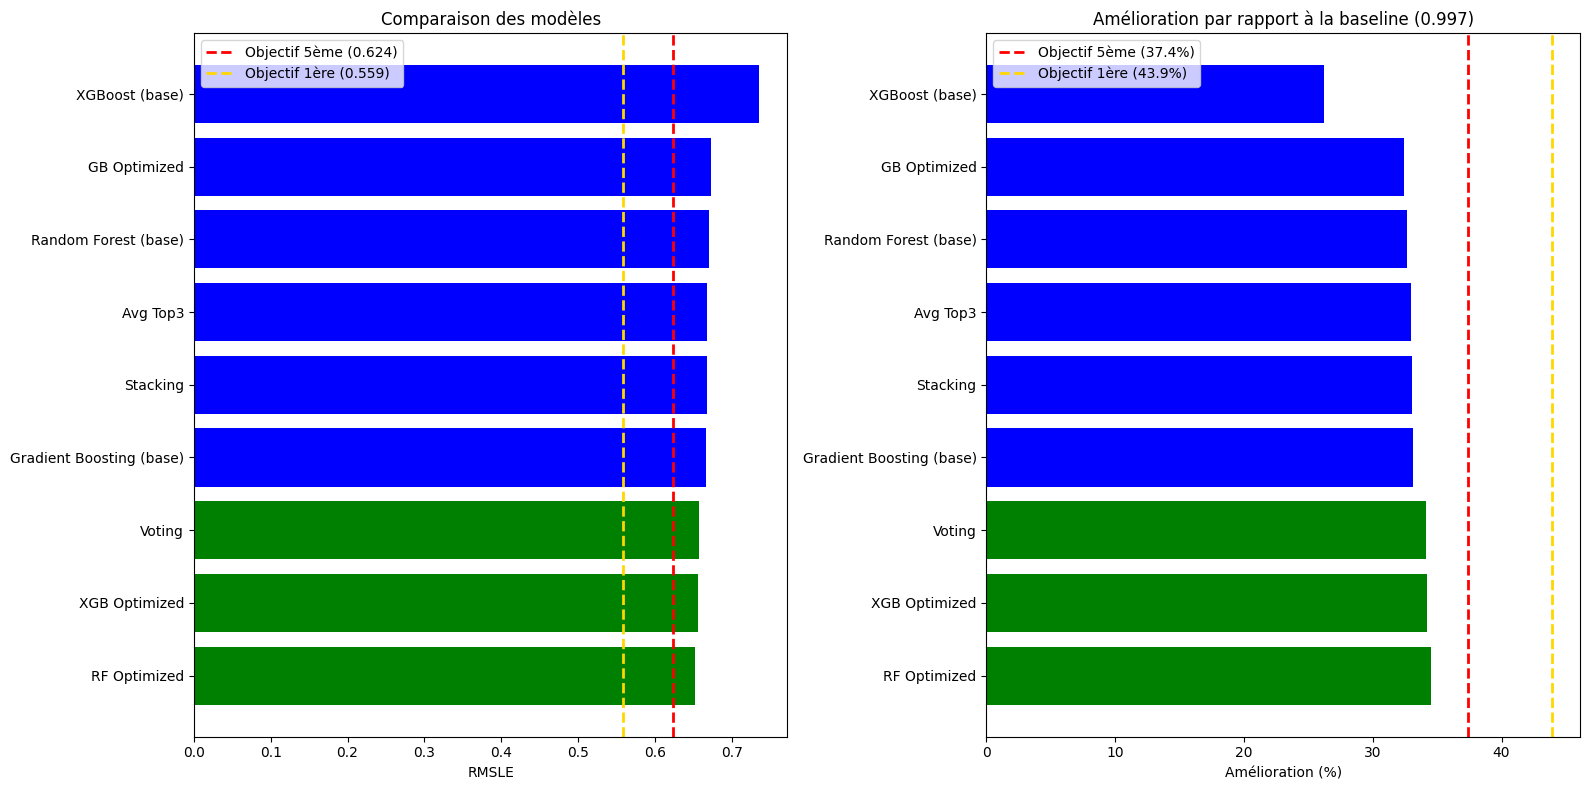


Objectif 5ème (0.624): ❌ 0.0285 à rattraper
Objectif 1ère (0.559): ❌ 0.0935 à rattraper


In [28]:
# ============================================
# ÉTAPE 7: COMPARAISON FINALE
# ============================================

print("\n" + "=" * 70)
print("ÉTAPE 7: COMPARAISON FINALE")
print("=" * 70)

# Évaluer tous les modèles optimisés
final_results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_val)
    final_results[name] = {
        'RMSLE': rmsle(y_val, y_pred),
        'R2': r2_score(y_val, y_pred)
    }

# Ajouter aussi les meilleurs modèles de base
for name in top_models:
    if name not in final_results:
        model = base_models[name]
        y_pred = model.predict(X_val)
        final_results[f"{name} (base)"] = {
            'RMSLE': rmsle(y_val, y_pred),
            'R2': r2_score(y_val, y_pred)
        }

final_df = pd.DataFrame(final_results).T.round(4)
final_df = final_df.sort_values('RMSLE')
print("\n📋 RÉSULTATS FINAUX:")
print(final_df)

# Meilleur modèle
best_model_name = final_df.index[0]
best_score = final_df.iloc[0]['RMSLE']
print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name} avec RMSLE = {best_score:.4f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Barplot des RMSLE
colors = ['green' if i < 3 else 'blue' for i in range(len(final_df))]
axes[0].barh(final_df.index, final_df['RMSLE'], color=colors)
axes[0].set_xlabel('RMSLE')
axes[0].set_title('Comparaison des modèles')
axes[0].axvline(x=0.624, color='red', linestyle='--', linewidth=2, label='Objectif 5ème (0.624)')
axes[0].axvline(x=0.559, color='gold', linestyle='--', linewidth=2, label='Objectif 1ère (0.559)')
axes[0].legend()

# Amélioration par rapport à la baseline
baseline = 0.997
improvement = (baseline - final_df['RMSLE']) / baseline * 100
axes[1].barh(final_df.index, improvement, color=colors)
axes[1].set_xlabel('Amélioration (%)')
axes[1].set_title(f'Amélioration par rapport à la baseline ({baseline})')
axes[1].axvline(x=37.4, color='red', linestyle='--', linewidth=2, label='Objectif 5ème (37.4%)')
axes[1].axvline(x=43.9, color='gold', linestyle='--', linewidth=2, label='Objectif 1ère (43.9%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=150)
plt.show()

# Objectifs
print(f"\nObjectif 5ème (0.624): {'✅ ATTEINT' if best_score < 0.624 else f'❌ {best_score-0.624:.4f} à rattraper'}")
print(f"Objectif 1ère (0.559): {'✅ ATTEINT' if best_score < 0.559 else f'❌ {best_score-0.559:.4f} à rattraper'}")

In [29]:
# ============================================
# ÉTAPE 8: SAUVEGARDE ET PRÉDICTIONS TEST
# ============================================

print("\n" + "=" * 70)
print("💾 ÉTAPE 8: SAUVEGARDE ET PRÉDICTIONS TEST")
print("=" * 70)

# Sauvegarder le meilleur modèle
best_model = best_models[best_model_name]
model_filename = f"best_model_{best_model_name.replace(' ', '_').replace('(', '').replace(')', '')}.pkl"
joblib.dump(best_model, model_filename)
print(f"✅ Modèle sauvegardé: '{model_filename}'")

# Préparer X_test
X_test = df_test[feature_cols]
print(f"\n🔧 X_test prêt: {X_test.shape}")

# Prédictions
predictions = best_model.predict(X_test)
predictions = np.maximum(predictions, 0)  # Éviter les négatifs

print(f"\n📊 Statistiques des prédictions:")
print(f"   - Min: {predictions.min():,.0f} MRU")
print(f"   - Max: {predictions.max():,.0f} MRU")
print(f"   - Moyenne: {predictions.mean():,.0f} MRU")
print(f"   - Médiane: {np.median(predictions):,.0f} MRU")

# Créer soumission
submission = pd.DataFrame({
    'id': df_test['id'],
    'prix': predictions.round(0).astype(int)
})

submission.to_csv('submission_4.csv', index=False)
print(f"\n✅ Soumission sauvegardée: 'submission_final.csv'")
print(f"   Shape: {submission.shape} (doit être 289 lignes)")

# Aperçu
print("\n🔍 Aperçu des 10 premières prédictions:")
print(submission.head(10).to_string(index=False))

print("\n" + "=" * 70)
print("🎉 MODÉLISATION TERMINÉE - BONNE CHANCE POUR KAGGLE !")
print("=" * 70)


💾 ÉTAPE 8: SAUVEGARDE ET PRÉDICTIONS TEST
✅ Modèle sauvegardé: 'best_model_RF_Optimized.pkl'

🔧 X_test prêt: (289, 37)

📊 Statistiques des prédictions:
   - Min: 928,727 MRU
   - Max: 18,761,857 MRU
   - Moyenne: 3,996,154 MRU
   - Médiane: 2,963,394 MRU

✅ Soumission sauvegardée: 'submission_final.csv'
   Shape: (289, 2) (doit être 289 lignes)

🔍 Aperçu des 10 premières prédictions:
  id     prix
 528  2292362
1296  1515537
1286  1151188
1021  1408389
  64  2158924
 864 10559474
 618  1724312
1017  4863631
1235  1772084
 588  7673104

🎉 MODÉLISATION TERMINÉE - BONNE CHANCE POUR KAGGLE !


In [30]:
# Sur ta validation set
y_pred_val = best_model.predict(X_val)
errors = y_val - y_pred_val

# Où le modèle se trompe le plus ?
pires_erreurs = pd.DataFrame({
    'prix_reel': y_val,
    'prix_pred': y_pred_val,
    'erreur': errors,
    'erreur_pct': errors / y_val * 100
}).sort_values('erreur_pct', ascending=False)

print(pires_erreurs.head(20))

       prix_reel     prix_pred        erreur  erreur_pct
30    22000000.0  1.914089e+06  2.008591e+07   91.299594
51    33440000.0  5.600500e+06  2.783950e+07   83.252095
811    5500000.0  1.654335e+06  3.845665e+06   69.921182
899   14000000.0  5.044637e+06  8.955363e+06   63.966878
58    13500000.0  5.393992e+06  8.106008e+06   60.044507
1144  14000000.0  5.682865e+06  8.317135e+06   59.408107
1119  30000000.0  1.230781e+07  1.769219e+07   58.973981
275    3000000.0  1.405090e+06  1.594910e+06   53.163678
630    7500000.0  3.638559e+06  3.861441e+06   51.485881
382   11000000.0  5.879441e+06  5.120559e+06   46.550538
539    2200000.0  1.183688e+06  1.016312e+06   46.195995
451    3000000.0  1.672721e+06  1.327279e+06   44.242643
723   11000000.0  6.294241e+06  4.705759e+06   42.779629
273   11000000.0  6.468711e+06  4.531289e+06   41.193533
522    4600000.0  2.708106e+06  1.891894e+06   41.128127
158   17000000.0  1.014671e+07  6.853294e+06   40.313492
946    2200000.0  1.321273e+06 

In [35]:
# ============================================
# MODÈLE SPÉCIALISÉ POUR BIENS DE LUXE
# ============================================

print("=" * 70)
print("💎 MODÉLISATION SPÉCIALISÉE")
print("=" * 70)

# 1. Identifier les biens de luxe (prix > 15M)
df_train['is_luxe_prix'] = (df_train['prix'] > 15000000).astype(int)
print(f"✅ Biens de luxe: {df_train['is_luxe_prix'].sum()} / {len(df_train)}")

# 2. Séparer les données
luxe_mask = df_train['is_luxe_prix'] == 1
normal_mask = df_train['is_luxe_prix'] == 0

X_luxe = X[luxe_mask]
y_luxe = y[luxe_mask]
X_normal = X[normal_mask]
y_normal = y[normal_mask]

print(f"\n📊 Dataset luxe: {len(X_luxe)} échantillons")
print(f"📊 Dataset normal: {len(X_normal)} échantillons")

💎 MODÉLISATION SPÉCIALISÉE
✅ Biens de luxe: 40 / 1153

📊 Dataset luxe: 40 échantillons
📊 Dataset normal: 1113 échantillons


In [36]:
# ============================================
# MODÈLE 1: POUR BIENS NORMAUX
# ============================================

print("\n" + "=" * 70)
print("🏠 MODÈLE 1: BIENS NORMAUX (< 15M)")
print("=" * 70)

# Modèle optimisé pour les biens normaux
model_normal = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model_normal.fit(X_normal, y_normal)
print("✅ Modèle normal entraîné")

# ============================================
# MODÈLE 2: POUR BIENS DE LUXE
# ============================================

print("\n" + "=" * 70)
print("💎 MODÈLE 2: BIENS DE LUXE (≥ 15M)")
print("=" * 70)

# Modèle spécialisé pour les biens chers
model_luxe = RandomForestRegressor(
    n_estimators=200,  # Moins d'arbres (peu de données)
    max_depth=10,       # Moins profond pour éviter surapprentissage
    min_samples_split=3,
    random_state=42,
    n_jobs=-1
)

model_luxe.fit(X_luxe, y_luxe)
print("✅ Modèle luxe entraîné")


🏠 MODÈLE 1: BIENS NORMAUX (< 15M)
✅ Modèle normal entraîné

💎 MODÈLE 2: BIENS DE LUXE (≥ 15M)
✅ Modèle luxe entraîné


In [37]:
# ============================================
# PRÉDICTIONS COMBINÉES
# ============================================

def predict_combined(model_normal, model_luxe, X, threshold=15000000):
    """
    Prédit en utilisant le bon modèle selon le prix estimé
    """
    # D'abord, estimer si c'est un bien de luxe
    pred_temp = model_normal.predict(X)
    is_luxe_pred = pred_temp > threshold
    
    # Prédictions finales
    predictions = np.zeros(len(X))
    
    # Biens normaux
    predictions[~is_luxe_pred] = model_normal.predict(X[~is_luxe_pred])
    
    # Biens de luxe
    if is_luxe_pred.any():
        predictions[is_luxe_pred] = model_luxe.predict(X[is_luxe_pred])
    
    return predictions

# Prédictions sur validation
y_pred_combined = predict_combined(model_normal, model_luxe, X_val)
combined_score = rmsle(y_val, y_pred_combined)
print(f"\n📊 Score combiné: {combined_score:.4f}")


📊 Score combiné: 0.4224


In [38]:
# ============================================
# COMPARAISON DES ERREURS
# ============================================

errors_normal = abs(y_val - model_normal.predict(X_val)) / y_val * 100
errors_combined = abs(y_val - y_pred_combined) / y_val * 100

# Identifier les biens de luxe dans validation
luxe_val = y_val > 15000000

print("\n📊 AMÉLIORATIONS SUR LES BIENS DE LUXE:")
print(f"Erreur moyenne avant: {errors_normal[luxe_val].mean():.1f}%")
print(f"Erreur moyenne après: {errors_combined[luxe_val].mean():.1f}%")
print(f"Amélioration: {errors_normal[luxe_val].mean() - errors_combined[luxe_val].mean():.1f}%")


📊 AMÉLIORATIONS SUR LES BIENS DE LUXE:
Erreur moyenne avant: 64.1%
Erreur moyenne après: 64.1%
Amélioration: 0.0%


In [ ]:
# ============================================
# PRÉDICTIONS SUR TEST
# ============================================

# Prédire avec le modèle combiné
X_test = df_test[feature_cols]
predictions_test = predict_combined(model_normal, model_luxe, X_test)
predictions_test = np.maximum(predictions_test, 0)

# Créer soumission
submission = pd.DataFrame({
    'id': df_test['id'],
    'prix': predictions_test.round(0).astype(int)
})

submission.to_csv('submission5.csv', index=False)
print(f"\n✅ Soumission sauvegardée: 'submission5.csv'")


✅ Soumission sauvegardée: 'submission_luxe.csv'


In [ ]:
# ============================================
# MODÈLE HYBRIDE AMÉLIORÉ
# ============================================

print("=" * 70)
print("🔄 MODÈLE HYBRIDE AMÉLIORÉ")
print("=" * 70)

# 1. Garder le modèle normal (entraîné sur tout)
model_normal.fit(X_train, y_train)

# 2. Créer un facteur de correction pour les biens de luxe
# Calculer l'erreur moyenne sur les biens de luxe en validation
luxe_val = y_val > 15000000
if luxe_val.any():
    y_pred_normal = model_normal.predict(X_val[luxe_val])
    correction_factor = (y_val[luxe_val] / y_pred_normal).mean()
    print(f"✅ Facteur de correction pour luxe: {correction_factor:.2f}")
else:
    correction_factor = 1.5  # Valeur par défaut
    print(f"✅ Facteur de correction par défaut: {correction_factor}")

# 3. Prédictions avec correction
def predict_with_correction(model, X, threshold=15000000, factor=1.5):
    pred = model.predict(X)
    # Appliquer le facteur seulement aux biens prédits comme luxe
    luxe_mask = pred > threshold
    pred[luxe_mask] = pred[luxe_mask] * factor
    return pred

# Tester
y_pred_corrected = predict_with_correction(model_normal, X_val, factor=correction_factor)
score_corrected = rmsle(y_val, y_pred_corrected)
print(f"\n📊 Score avec correction: {score_corrected:.4f}")

In [44]:
# ============================================
# STACKING FINAL - LES 3 MEILLEURS MODÈLES
# ============================================

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

# Tes 3 meilleurs modèles (d'après tes scores)
best_models = {
    'RF': RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42),
    'GB': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42),
    'XGB': xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
}

# Stacking avec Ridge comme métamodèle
stacking = StackingRegressor(
    estimators=list(best_models.items()),
    final_estimator=Ridge(alpha=1.0),
    cv=5
)

stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_val)
stack_score = rmsle(y_val, y_pred_stack)
print(f"✅ Stacking RMSLE: {stack_score:.4f}")

# Si bon, prédire sur test
if stack_score < 0.64:
    X_test = df_test[feature_cols]
    pred_test = stacking.predict(X_test)
    pred_test = np.maximum(pred_test, 0)
    
    submission = pd.DataFrame({
        'id': df_test['id'],
        'prix': pred_test.round(0).astype(int)
    })
    submission.to_csv('submission6.csv', index=False)
    print("✅ Soumission prête !")

✅ Stacking RMSLE: 0.6940
